## Deconvolution using geneformer (pseudobulk + single-cell reference) - Geneformer
This tutorial demonstrates how to use DECONVersation to run and evaluate deconvolution on pseudobulk data, using built-in pseudobulk simulation functions available within the package. Geneformer embeddings are used throughout, though the workflow is fully adaptable to Cell2Sentence or CellHermes. The tutorial covers the full pipeline: generating pseudobulk data, constructing signature matrices, extracting Geneformer embeddings from both the pseudobulk and single-cell reference signature datasets, and estimating cell type proportions via NNLS. Predicted proportions are then evaluated against ground truth using RMSE and Pearson correlation to benchmark deconvolution performance. <br>

### Step 0: Load reference data (scRNA-seq)

In [1]:
# Append path to deconversation modules
import sys
import os
import scanpy as sc
import numpy as np
import pandas as pd
#sys.path.append('../../deconversation')
sys.path.append("/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages")

/nfs/home/aoku/.local/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
!which python

/nfs/sw/easybuild/software/Miniforge3/24.1.2-0/bin/python


In [23]:
import deconversation
from deconversation import embeddings as em
from deconversation import preprocessing as pr
from deconversation import deconvolution as de
from deconversation import visualization as vs 
from deconversation import pseudobulk as pb 

In [4]:
# Path to single-cell RNAseq data 
path = "/gpfs/commons/groups/compbio/projects/CZI_endom/publicData/HECA/endometriumAtlasV2_cells_with_counts.h5ad"
path_ref = "/gpfs/commons/groups/compbio/projects/CZI_endom/publicData/HECA/endometriumAtlasV2_nuclei.h5ad"

### Step 1: Prep data for Geneformer

In [5]:
# Read the h5ad file (just to explore columns and variables)
adata = sc.read_h5ad(path)

# Subset to select cell types
adata = adata[adata.obs["dataset"].isin(['Mareckova'])]
adata = adata[adata.obs["celltype"].isin(['eStromal', 'dStromal_mid', 'Immune_Lymphoid', 
                                          'dStromal_early', 'Venous', 'eHormones', 'Glandular', 
                                          'SOX9_functionalis_II', 'preGlandular'])]

# Remove unmapped genes
adata.var.index = adata.var["gene_ids-0-Fonseca"]
adata = adata[:, adata.var.index != "nan"]
adata = adata[:, adata.var.index.notnull()]

/scratch/ipykernel_3649581/3145637199.py:11: ImplicitModificationWarning: Trying to modify index of attribute `.var` of view, initializing view as actual.
  adata.var.index = adata.var["gene_ids-0-Fonseca"]
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [6]:
adata.obs["celltype"].value_counts()

celltype
eStromal                14370
dStromal_early           8711
dStromal_mid             8036
SOX9_functionalis_II     5502
preGlandular             5079
Immune_Lymphoid          4354
eHormones                4032
Glandular                3755
Venous                   3206
Name: count, dtype: int64

In [7]:
# Read the h5ad file (just to explore columns and variables)
adata_ref = sc.read_h5ad(path_ref)

# # Subset to select cell types
adata_ref = adata_ref[adata_ref.obs["celltype"].isin(['eStromal', 'dStromal_mid', 'Immune_Lymphoid', 
                                          'dStromal_early', 'Venous', 'eHormones', 'Glandular', 
                                          'SOX9_functionalis_II', 'preGlandular'])]

# Remove unmapped genes
#adata_ref.var.index = adata_ref.var["gene_ids-0"]
adata_ref = adata_ref[:, adata_ref.var.index != "nan"]
adata_ref = adata_ref[:, adata_ref.var.index.notnull()]

In [8]:
adata_ref.var.head()

,gene_ids-0,feature_types-0,n_cells-0,gene_ids-1,feature_types-1,n_cells-1,gene_ids-10,feature_types-10,n_cells-10,gene_ids-11,...,mean_counts,pct_dropout_by_counts,total_counts,n_cells,highly_variable,highly_variable_rank,means,variances,variances_norm,highly_variable_nbatches
A1BG,ENSG00000121410,Gene Expression,327.0,ENSG00000121410,Gene Expression,1740.0,ENSG00000121410,Gene Expression,1200.0,ENSG00000121410,...,0.068373,94.009317,58285.0,44065,False,NaN,0.091346,0.114612,0.807159,0
A1BG-AS1,ENSG00000268895,Gene Expression,395.0,ENSG00000268895,Gene Expression,1140.0,ENSG00000268895,Gene Expression,957.0,ENSG00000268895,...,0.049035,95.617140,41800.0,35085,False,NaN,0.073072,0.087793,0.823837,0
A1CF,ENSG00000148584,Gene Expression,39.0,ENSG00000148584,Gene Expression,31.0,ENSG00000148584,Gene Expression,18.0,nan,...,0.001425,99.872369,1215.0,1062,False,NaN,0.002213,0.002825,0.862828,0
A2M,ENSG00000175899,Gene Expression,828.0,ENSG00000175899,Gene Expression,1875.0,ENSG00000175899,Gene Expression,1956.0,ENSG00000175899,...,0.278094,83.491719,237063.0,120469,False,685.0,0.389485,2.281395,2.734381,3
A2M-AS1,ENSG00000245105,Gene Expression,100.0,ENSG00000245105,Gene Expression,339.0,ENSG00000245105,Gene Expression,568.0,ENSG00000245105,...,0.015537,98.558754,13245.0,11277,False,NaN,0.022214,0.025878,0.918067,0


In [9]:
adata_ref.obs["celltype"].value_counts()

celltype
eStromal                46062
SOX9_functionalis_II    38538
preGlandular            18101
Immune_Lymphoid         16948
dStromal_early          16576
Glandular               15355
dStromal_mid            13676
eHormones               13459
Venous                   3394
Name: count, dtype: int64

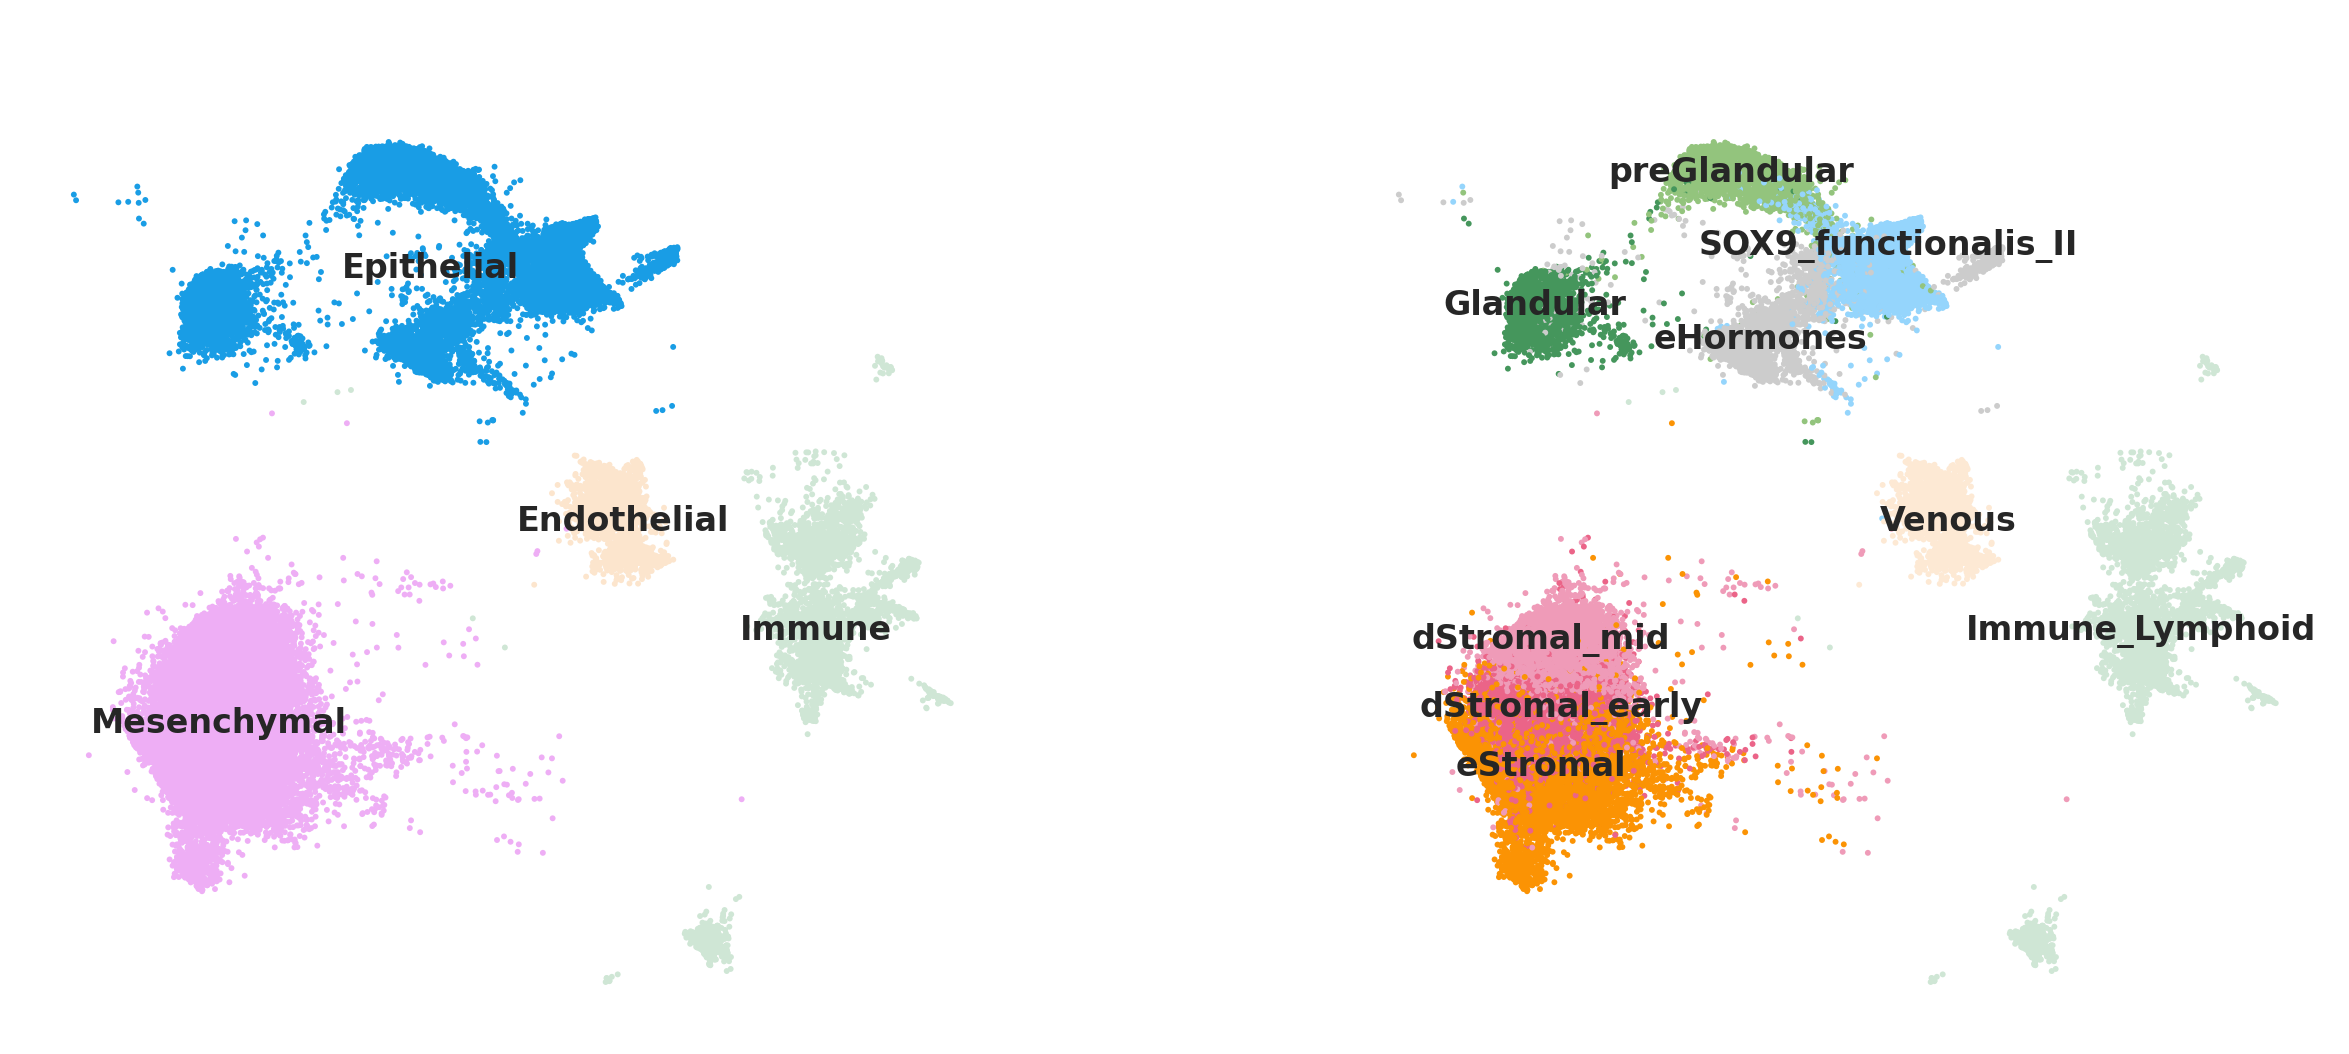

In [9]:
import scanpy as sc

# Set global publication-ready defaults
sc.set_figure_params(dpi=150, frameon=False, facecolor="white")

# Enhanced plot call
sc.pl.umap(
    adata,
    color=["lineage", "celltype"],
    title=[" ", " "],
    legend_loc="on data",        # Places text on cluster centroids to reduce legend clutter
    legend_fontsize=8,
    legend_fontweight="bold",
    size=8,                     # Prevents overplotting (adjust based on cell count)
    ncols=2,                     # Places plots side-by-side
    wspace=0.25,                 # Spacing between plots
    #frameon=True,
    sort_order=False             # Shuffles cell rendering order to avoid masking small groups
)

In [10]:
#sc.pl.umap(adata, color='celltype', frameon=False, size=15, palette='tab20')

In [11]:
#sc.pl.umap(adata_ref, color='celltype', frameon=False, size=15, palette='tab20')

### Step 2: Create pseudobulk

In [12]:
# Create pseudobulk and cell type prortions (ground truth)
pseudo_bulk, cell_prop = pb.generate_pseudobulk(adata = adata,
                                             cell_type_col = "celltype", 
                                             n_pseudobulks = 500,
                                             target_proportion_min = 0.10, 
                                             target_proportion_max = 0.80, 
                                             n_cells_per_pseudobulk = 1000, 
                                             random_state = 42 
                                            )

In [13]:
pseudo_bulk.head()

gene_ids-0-Fonseca,ENSG00000121410,ENSG00000175899,ENSG00000128274,ENSG00000094914,ENSG00000081760,ENSG00000109576,ENSG00000103591,ENSG00000115977,ENSG00000087884,ENSG00000127837,...,ENSG00000214655,ENSG00000185453,ENSG00000086827,ENSG00000174442,ENSG00000198205,ENSG00000198455,ENSG00000070476,ENSG00000162378,ENSG00000159840,ENSG00000074755
SOX9_functionalis_II_PB1,157.315033,217.779404,139.927643,107.392952,102.560364,101.420441,127.671265,283.776184,258.739227,313.969696,...,146.126083,43.599747,57.166832,57.903728,14.078470,37.190372,82.945396,264.960083,447.041168,128.092850
dStromal_mid_PB2,222.859879,295.543610,82.930138,120.276207,89.394379,102.177216,52.771145,361.302551,175.868866,273.345886,...,126.194000,54.351410,51.662312,39.830914,7.765866,36.496849,79.533569,348.799011,897.262024,140.834000
Venous_PB3,140.549744,1930.760864,318.499359,120.153114,78.342400,36.936054,103.976341,342.703369,309.126221,332.337402,...,176.314072,60.750175,77.074524,50.183838,17.973970,41.342766,111.626625,259.191498,573.099792,212.046570
preGlandular_PB4,93.298836,210.397003,105.085770,111.030220,89.179169,153.511993,101.492676,211.107651,304.612610,325.533844,...,152.752090,30.382133,57.375053,46.173111,17.540382,30.832708,83.077766,227.581024,362.392578,142.699844
eHormones_PB5,154.714828,320.047028,142.140656,114.081505,79.971527,90.718605,109.743820,314.191925,241.653870,286.178741,...,153.945084,73.117867,56.246273,65.009430,15.297888,37.697624,82.605522,257.303619,524.480652,143.121307


In [14]:
#pseudo_bulk.to_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/scripts/pseudobulk_data_heca_Mareckova_single_cell_only.csv")

In [15]:
#cell_prop.to_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/scripts/pseudobulk_data_heca_Mareckova_single_cell_only_cell_prop.csv")

In [19]:
#cell_prop = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/scripts/pseudobulk_data_heca_Mareckova_single_cell_only_cell_prop.csv", index_col=0)

In [20]:
cell_prop.head()

,eStromal,Venous,preGlandular,Immune_Lymphoid,eHormones,SOX9_functionalis_II,dStromal_mid,dStromal_early,Glandular
SOX9_functionalis_II_PB1,0.171,0.034,0.065,0.055,0.044,0.362,0.105,0.110,0.054
dStromal_mid_PB2,0.059,0.017,0.029,0.025,0.016,0.023,0.766,0.036,0.029
Venous_PB3,0.106,0.612,0.035,0.027,0.031,0.036,0.047,0.077,0.029
preGlandular_PB4,0.119,0.032,0.519,0.038,0.032,0.044,0.093,0.093,0.030
eHormones_PB5,0.201,0.059,0.087,0.070,0.209,0.078,0.124,0.117,0.055


### Step 3: Create signature matrix

In [10]:
# Create signature matrix from single cell data
sig_mat = pr.create_signature_matrix(adata = adata_ref,
                                  sample_col = "sample", # sample id column
                                  cell_type_col = "celltype",
                                  groupby = "celltype",
                                  sample_ids = None,
                                  output_path = None)

# Transpose for embedding extraction
# Columns should be gene names or ensembl ids (ensembl ids for geneformer)
sig_mat = sig_mat.T

/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/deconversation/preprocessing.py:247: UserWarning: Expression matrix contains non-integer values. Raw counts are expected. 
  warnings.warn(
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/deconversation/preprocessing.py:259: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  signature = expr.groupby(groupby).mean().T


In [11]:
sig_mat.head()

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,A3GALT2,A4GALT,...,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1
celltype,,,,,,,,,,,,,,,,,,,,,
SOX9_functionalis_II,0.031350,0.010910,0.003604,0.085364,0.009395,0.018540,0.315712,0.000116,0.001889,0.201908,...,0.144578,0.087287,0.027259,0.003856,0.011537,0.452550,0.009015,0.372470,0.111210,0.422845
preGlandular,0.031814,0.009524,0.000541,0.108921,0.007264,0.038818,0.227653,0.000041,0.001538,0.080537,...,0.145544,0.084857,0.033549,0.004436,0.010733,0.409723,0.026528,0.321887,0.118353,0.493830
Glandular,0.036877,0.011069,0.002028,0.204764,0.004437,0.022719,1.958125,0.000035,0.003486,0.139029,...,0.141178,0.080666,0.010566,0.004593,0.009883,0.521152,0.007031,0.332832,0.157526,0.583567
eHormones,0.035515,0.014339,0.001955,0.116688,0.008188,0.017235,0.484939,0.000000,0.003349,0.194835,...,0.145207,0.090055,0.023039,0.004852,0.014022,0.541487,0.006449,0.391435,0.164065,0.448435
eStromal,0.093458,0.085751,0.000880,0.129728,0.022028,0.011167,0.069346,0.000000,0.006646,0.069730,...,0.124160,0.073676,0.020734,0.004784,0.012763,0.382653,0.005754,0.559452,0.307520,0.448205


In [12]:
sig_mat.to_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/scripts/sig_matrix_endometriumAtlasV2_nuclei_gene_names.csv")

The signature matrix is constructed by averaging gene expression across the selected cell types, requiring no predefined gene markers. To build a signature matrix from a specific subset of samples, pass the desired sample IDs as a list. Here, all available samples are used, so `sample_id` is set to None.

### Step 4: Extract Geneformer Embeddings

In [26]:
sig_mat_gf_embed = em.extract_embs(
    bulk_df = sig_mat, # sample x ensembl id
    mode = "geneformer", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/HECA_nuc/260820_geneformer_cellClassifier_gf_finetune/ksplit1/", # Default geneformer model
    layer_to_quant = 18,
    delete_temp_files = True # if True, delete all temporary files created whiile extracting embeddings
)

#ctheodoris/Geneformer

... storing 'cell_type' as categorical


Bulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 13.54it/s]

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.



/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:740: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['SOX9_functionalis_II', 'preGlandular', 'Glandular', 'eHormones', 'eStromal']

    Inferred to be: categorical

  value_idx = self._prep_dim_index(value.index, attr)
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:787: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/geneformer/tokenizer.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integ

...

Some weights of BertForMaskedLM were not initialized from the model checkpoint at /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/HECA_nuc/260820_geneformer_cellClassifier_gf_finetune/ksplit1/ and are newly initialized: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading Geneformer model...


2026-08-20 16:15:18,982 [WARNING] CLS token present in token dictionary, excluding from average.
2026-08-20 16:15:18,982 [WARNING] EOS token present in token dictionary, excluding from average.


Loading tokenized dataset...
Extracting Geneformer embeddings...


  0%|          | 0/1 [00:00<?, ?it/s]

In [27]:
pseudo_bulk_embed = em.extract_embs(
    bulk_df = pseudo_bulk, # sample x ensembl id
    mode = "geneformer",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/HECA_nuc/260820_geneformer_cellClassifier_gf_finetune/ksplit1/", # Default geneformer model
    layer_to_quant = 18,
    delete_temp_files = True
)

... storing 'cell_type' as categorical


Bulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 23.02it/s]
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:787: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/geneformer/tokenizer.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
 

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.


Map (num_proc=1):   0%|          | 0/500 [00:00<?, ? examples/s]

...

Some weights of BertForMaskedLM were not initialized from the model checkpoint at /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/HECA_nuc/260820_geneformer_cellClassifier_gf_finetune/ksplit1/ and are newly initialized: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading Geneformer model...


2026-08-20 16:15:24,418 [WARNING] CLS token present in token dictionary, excluding from average.
2026-08-20 16:15:24,419 [WARNING] EOS token present in token dictionary, excluding from average.


Loading tokenized dataset...
Extracting Geneformer embeddings...


  0%|          | 0/10 [00:00<?, ?it/s]

### Step 5: Run Non-Negative Least Squares (NNLS)

In [28]:
#from deconvolution import *

In [29]:
# Run NNLS
results = de.run_all_deconv(bulk_df=pseudo_bulk_embed.T, signature_df=sig_mat_gf_embed.T)

Condition number: 4.98.
~1-10: signatures are well separated; NNLS is usually hard to improve materially with another solver.
Smallest singular value: 0.4124.
If value is close to zero, the signature matrix is ill-conditioned; estimated proportions may be unstable.
Max pairwise cosine similarity between cell types: 0.7364.
Most similar pair: eStromal vs dStromal_early.
If value is close to 1, these cell types are highly similar and difficult to resolve separately.
Running solver: nnls
Finished in 0.09 seconds.
Running solver: nnls_mod
Finished in 0.08 seconds.
Running solver: dwls
Finished in 0.45 seconds.
Running solver: simplex
Finished in 0.67 seconds.
Running solver: ridge_simplex
Finished in 0.72 seconds.
Running solver: dwls_simplex
Finished in 1.19 seconds.
Running solver: ridge
Finished in 0.34 seconds.
Running solver: elasticnet
Finished in 0.11 seconds.
Running solver: nusvr
Finished in 16.60 seconds.
Running solver: simplex_nnls
Finished in 0.38 seconds.
Running solver: grad

/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/deconversation/deconvolution.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  references = torch.tensor(references, dtype=torch.float32)
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/deconversation/deconvolution.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mixture = torch.tensor(mixture, dtype=torch.float32)


Finished in 0.81 seconds.


In [42]:
cell_prop_pred = results["nnls"]

In [48]:
cell_prop_pred.index.name = None
cell_prop_pred.to_csv("../results/czi_cell_type/FinetunedGFNucPlus_estimated_proportions_HECA_single_nuc_ref.csv")

### Step 6: Evaluate estimated proportions

In [26]:
from deconversation import evaluation as ev

In [45]:
corr = pd.DataFrame(ev.compute_correlation(true_df=cell_prop, 
                    pred_df=cell_prop_pred, 
                    return_per_celltype=True))
corr.columns = ["corr_overall", "corr_per_celltype"]

rmse = pd.DataFrame(ev.compute_rmse(true_df=cell_prop, 
                    pred_df=cell_prop_pred, 
                    return_per_celltype=True))
rmse.columns = ["rmse_overall", "rmse_per_celltype"]

pd.concat([corr, rmse], axis=1)

,corr_overall,corr_per_celltype,rmse_overall,rmse_per_celltype
eStromal,0.647616,0.889673,0.146484,0.127193
Venous,0.647616,0.920230,0.146484,0.105310
preGlandular,0.647616,0.749350,0.146484,0.206277
Immune_Lymphoid,0.647616,0.875220,0.146484,0.086969
eHormones,0.647616,0.892590,0.146484,0.083190
SOX9_functionalis_II,0.647616,0.960183,0.146484,0.141752
dStromal_mid,0.647616,0.890212,0.146484,0.070139
dStromal_early,0.647616,0.549895,0.146484,0.276152
Glandular,0.647616,0.855325,0.146484,0.086847


In [46]:
#from visualization import *

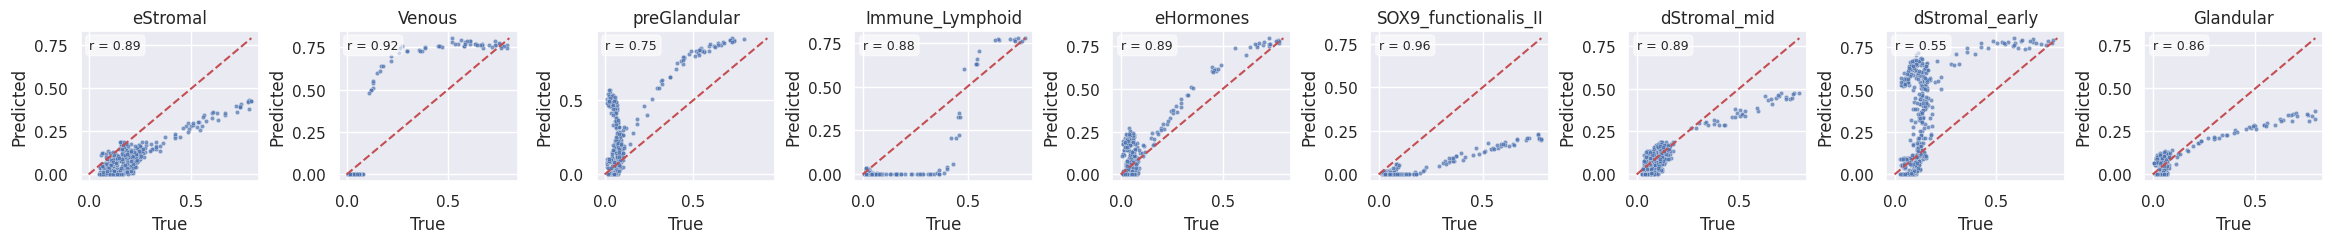

In [47]:
vs.plot_true_vs_predicted(
    y_true_df = cell_prop, # sample (rows) x cell type (columns)
    y_pred_df = cell_prop_pred, # sample (rows) x cell type (columns)
    stratify_by_celltype= True,
    dot_size = 10,n_cols=9,
    figsize_per_plot = (2.6,2.6)
)

### Counts

In [119]:
# Run NNLS
results_counts = de.run_all_deconv(bulk_df=pseudo_bulk.T, signature_df=sig_mat.T, solvers=["nnls", "elasticnet"])

Condition number: 22.23.
~1-10: signatures are well separated; NNLS is usually hard to improve materially with another solver.
Smallest singular value: 0.1263.
If value is close to zero, the signature matrix is ill-conditioned; estimated proportions may be unstable.
Max pairwise cosine similarity between cell types: 0.9739.
Most similar pair: eStromal vs dStromal_early.
If value is close to 1, these cell types are highly similar and difficult to resolve separately.
Running solver: nnls
Finished in 0.62 seconds.
Running solver: elasticnet
Finished in 4.62 seconds.


In [120]:
cell_prop_pred = results_counts["nnls"]

In [121]:
cell_prop_pred.index.name = None
cell_prop_pred.to_csv("../results/czi_cell_type/Counts_estimated_proportions_HECA_single_nuc_ref.csv")

In [124]:
corr = pd.DataFrame(ev.compute_correlation(true_df=cell_prop, 
                    pred_df=cell_prop_pred, 
                    return_per_celltype=True))
corr.columns = ["corr_overall", "corr_per_celltype"]

rmse = pd.DataFrame(ev.compute_rmse(true_df=cell_prop, 
                    pred_df=cell_prop_pred, 
                    return_per_celltype=True))
rmse.columns = ["rmse_overall", "rmse_per_celltype"]

pd.concat([corr, rmse], axis=1)

/nfs/home/aoku/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/nfs/home/aoku/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,corr_overall,corr_per_celltype,rmse_overall,rmse_per_celltype
eStromal,0.234175,NaN,0.239294,0.237393
Venous,0.234175,0.993846,0.239294,0.048123
preGlandular,0.234175,0.972768,0.239294,0.128960
Immune_Lymphoid,0.234175,0.915521,0.239294,0.143465
eHormones,0.234175,NaN,0.239294,0.163050
SOX9_functionalis_II,0.234175,0.973883,0.239294,0.138279
dStromal_mid,0.234175,0.487817,0.239294,0.574903
dStromal_early,0.234175,NaN,0.239294,0.181013
Glandular,0.234175,0.833170,0.239294,0.102391


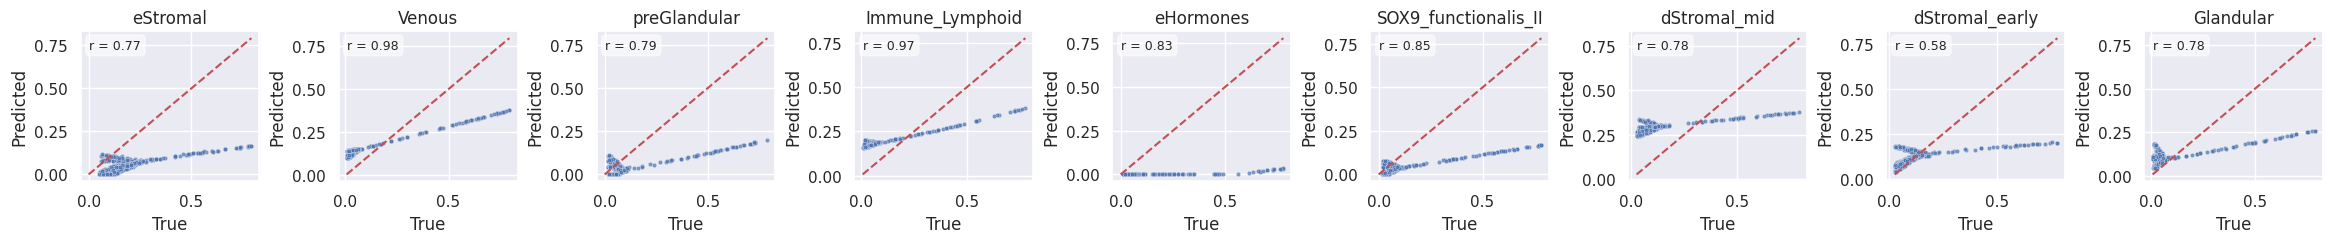

In [28]:
plot_true_vs_predicted(
    y_true_df = cell_prop, # sample (rows) x cell type (columns)
    y_pred_df = cell_prop_pred, # sample (rows) x cell type (columns)
    stratify_by_celltype= True,
    dot_size = 10,n_cols=9,
    figsize_per_plot = (2.6,2.6)
)

### MuSiC

In [21]:
music_results = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/results/MuSiC_estimated_proportions_HECA_single_nuc_ref.csv", index_col=0)

In [25]:
corr = pd.DataFrame(ev.compute_correlation(true_df=cell_prop, 
                    pred_df=music_results, 
                    return_per_celltype=True))
corr.columns = ["corr_overall", "corr_per_celltype"]

rmse = pd.DataFrame(ev.compute_rmse(true_df=cell_prop, 
                    pred_df=music_results, 
                    return_per_celltype=True))
rmse.columns = ["rmse_overall", "rmse_per_celltype"]

pd.concat([corr, rmse], axis=1)

,corr_overall,corr_per_celltype,rmse_overall,rmse_per_celltype
eStromal,0.415086,NaN,0.206014,0.237393
Venous,0.415086,0.994926,0.206014,0.051112
preGlandular,0.415086,0.892332,0.206014,0.070794
Immune_Lymphoid,0.415086,0.966556,0.206014,0.089790
eHormones,0.415086,0.680001,0.206014,0.154228
SOX9_functionalis_II,0.415086,0.725663,0.206014,0.113206
dStromal_mid,0.415086,0.535701,0.206014,0.482719
dStromal_early,0.415086,0.657771,0.206014,0.153499
Glandular,0.415086,0.859361,0.206014,0.129432


/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/deconversation/visualization.py:159: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(x, y)


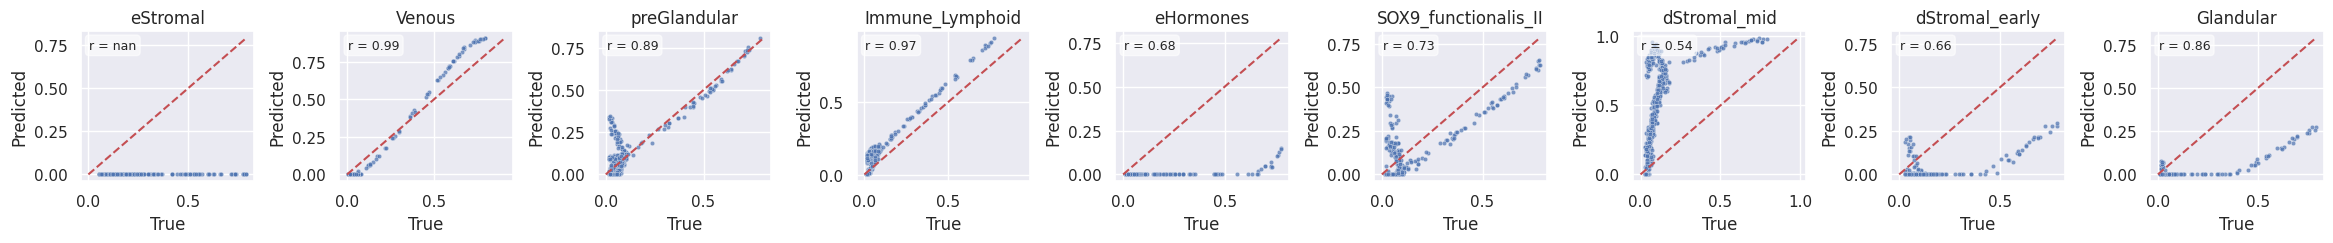

In [26]:
vs.plot_true_vs_predicted(
    y_true_df = cell_prop, # sample (rows) x cell type (columns)
    y_pred_df = music_results, # sample (rows) x cell type (columns)
    stratify_by_celltype= True,
    dot_size = 10,n_cols=9,
    figsize_per_plot = (2.6,2.6)
)

### DWLS

In [29]:
dwls_results = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/scripts/pseudobulk_data_heca_Mareckova_single_cell_only_proportions_dwls.csv", index_col=0)

In [28]:
# /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/scripts/pseudobulk_data_heca_Mareckova_single_cell_only_proportions_dwls.csv
# /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/scripts/pseudobulk_data_heca_Mareckova_single_cell_only_proportions_bp.csv

In [30]:
corr = pd.DataFrame(ev.compute_correlation(true_df=cell_prop, 
                    pred_df=dwls_results, 
                    return_per_celltype=True))
corr.columns = ["corr_overall", "corr_per_celltype"]

rmse = pd.DataFrame(ev.compute_rmse(true_df=cell_prop, 
                    pred_df=dwls_results, 
                    return_per_celltype=True))
rmse.columns = ["rmse_overall", "rmse_per_celltype"]

pd.concat([corr, rmse], axis=1)

,corr_overall,corr_per_celltype,rmse_overall,rmse_per_celltype
eStromal,0.861257,0.976814,0.090006,0.114449
Venous,0.861257,0.976681,0.090006,0.118279
preGlandular,0.861257,0.979327,0.090006,0.050207
Immune_Lymphoid,0.861257,0.995527,0.090006,0.041160
eHormones,0.861257,0.951299,0.090006,0.099932
SOX9_functionalis_II,0.861257,0.994004,0.090006,0.040735
dStromal_mid,0.861257,0.876645,0.090006,0.143202
dStromal_early,0.861257,0.923737,0.090006,0.080107
Glandular,0.861257,0.971204,0.090006,0.055103


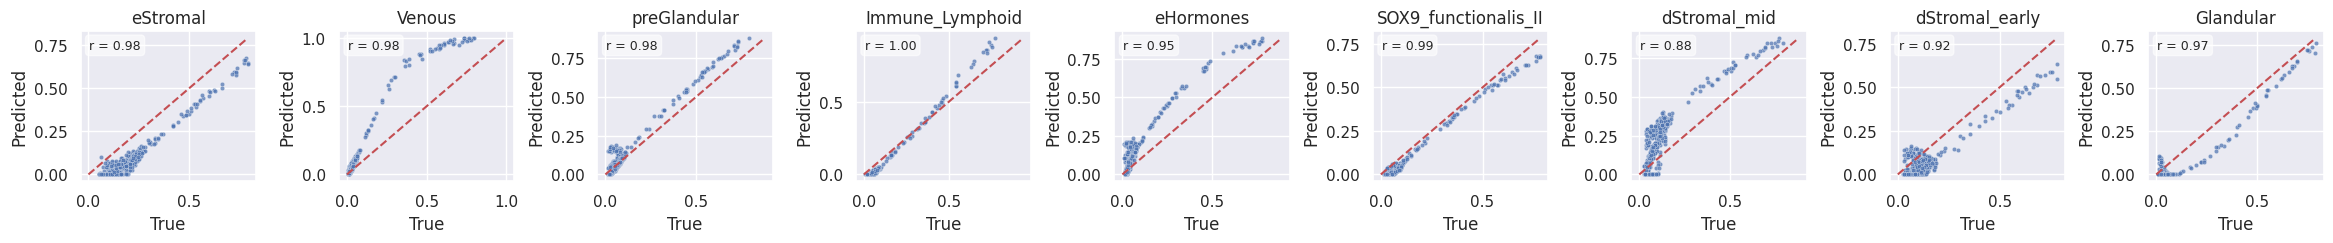

In [35]:
vs.plot_true_vs_predicted(
    y_true_df = cell_prop, # sample (rows) x cell type (columns)
    y_pred_df = dwls_results, # sample (rows) x cell type (columns)
    stratify_by_celltype= True,
    dot_size = 10,n_cols=9,
    figsize_per_plot = (2.6,2.6)
)

#### BayesPrism

In [33]:
bp_results = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/scripts/pseudobulk_data_heca_Mareckova_single_cell_only_proportions_bp.csv", index_col=0)

In [34]:
corr = pd.DataFrame(ev.compute_correlation(true_df=cell_prop, 
                    pred_df=bp_results, 
                    return_per_celltype=True))
corr.columns = ["corr_overall", "corr_per_celltype"]

rmse = pd.DataFrame(ev.compute_rmse(true_df=cell_prop, 
                    pred_df=bp_results, 
                    return_per_celltype=True))
rmse.columns = ["rmse_overall", "rmse_per_celltype"]

pd.concat([corr, rmse], axis=1)

,corr_overall,corr_per_celltype,rmse_overall,rmse_per_celltype
eStromal,0.552551,0.944512,0.185112,0.183938
Venous,0.552551,0.997091,0.185112,0.078955
preGlandular,0.552551,0.971569,0.185112,0.055775
Immune_Lymphoid,0.552551,0.998456,0.185112,0.029013
eHormones,0.552551,0.993893,0.185112,0.072904
SOX9_functionalis_II,0.552551,0.993045,0.185112,0.085036
dStromal_mid,0.552551,0.559514,0.185112,0.486327
dStromal_early,0.552551,0.893266,0.185112,0.109650
Glandular,0.552551,0.975661,0.185112,0.057414


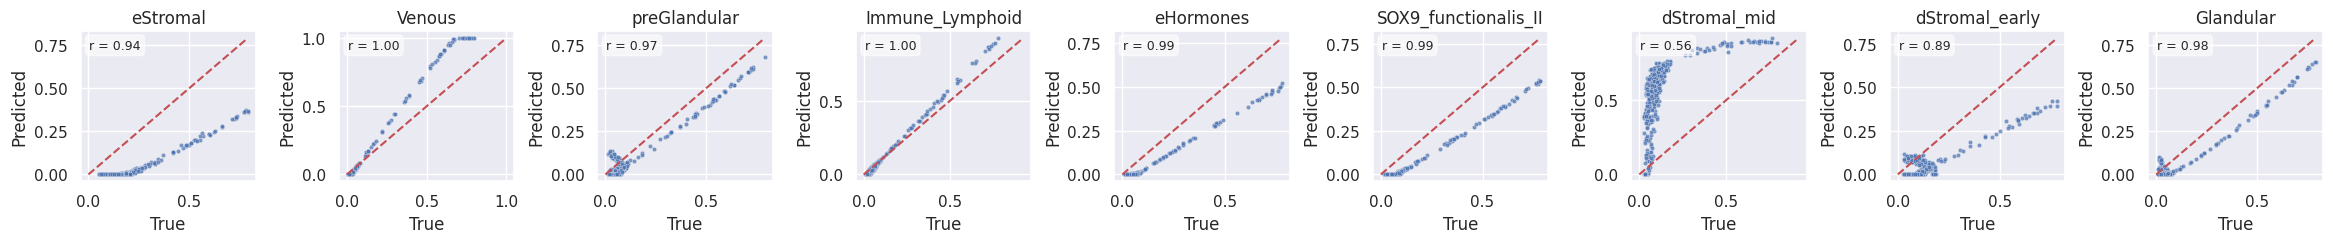

In [36]:
vs.plot_true_vs_predicted(
    y_true_df = cell_prop, # sample (rows) x cell type (columns)
    y_pred_df = bp_results, # sample (rows) x cell type (columns)
    stratify_by_celltype= True,
    dot_size = 10,n_cols=9,
    figsize_per_plot = (2.6,2.6)
)

In [31]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

def plot_results_metrics(results_path, true_df):
    rows = []

    for csv_path in glob.glob(os.path.join(results_path, "*.csv")):
        sample_name = os.path.basename(csv_path).split("_")[0]
        pred_df = pd.read_csv(csv_path, index_col=0)

        corr = pd.DataFrame(
            ev.compute_correlation(
                true_df=true_df,
                pred_df=pred_df,
                return_per_celltype=True
            )
        )
        corr.columns = ["corr_overall", "corr_per_celltype"]

        rmse = pd.DataFrame(
            ev.compute_rmse(
                true_df=true_df,
                pred_df=pred_df,
                return_per_celltype=True
            )
        )
        rmse.columns = ["rmse_overall", "rmse_per_celltype"]

        metrics = pd.concat([corr, rmse], axis=1)

        rows.append({
            "sample": sample_name,
            "corr_overall": metrics["corr_overall"].iloc[0],
            "rmse_overall": metrics["rmse_overall"].iloc[0]
        })

    results_df = pd.DataFrame(rows)

    corr_df = results_df.sort_values("corr_overall", ascending=False)
    rmse_df = results_df.sort_values("rmse_overall", ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4), facecolor="white")

    for ax in axes:
        ax.set_facecolor("white")
        ax.grid(False)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(True)
        ax.spines["bottom"].set_visible(True)

    axes[0].bar(corr_df["sample"], corr_df["corr_overall"])
    axes[0].set_title("")
    axes[0].set_xlabel("Sample")
    axes[0].set_ylabel("Cor")
    axes[0].tick_params(axis="x", rotation=90)

    axes[1].bar(rmse_df["sample"], rmse_df["rmse_overall"])
    axes[1].set_title("")
    axes[1].set_xlabel("Sample")
    axes[1].set_ylabel("RMSE")
    axes[1].tick_params(axis="x", rotation=90)

    plt.tight_layout()
    plt.show()

    return results_df

/nfs/home/aoku/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/nfs/home/aoku/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/nfs/home/aoku/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/nfs/home/aoku/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/nfs/home/aoku/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/nfs/home/aoku/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


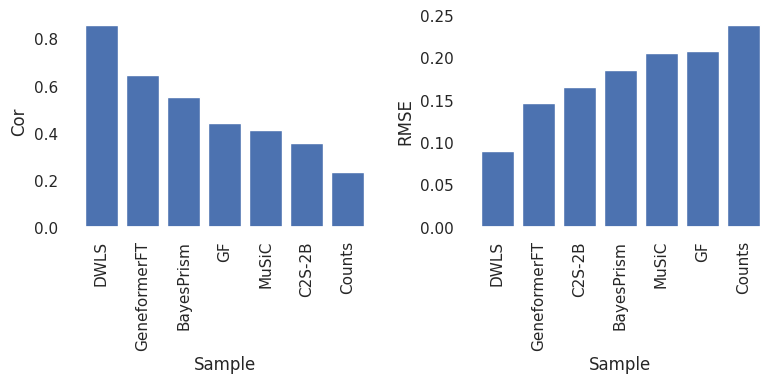

,sample,corr_overall,rmse_overall
0,GF,0.441352,0.208362
1,C2S-2B,0.359090,0.165029
2,DWLS,0.861257,0.090006
3,GeneformerFT,0.647616,0.146484
4,BayesPrism,0.552551,0.185112
5,Counts,0.234175,0.239294
6,MuSiC,0.415086,0.206014


In [32]:
plot_results_metrics(results_path = "../results/czi_cell_type/", true_df=cell_prop)

In [30]:
results_df

NameError: name 'results_df' is not defined

In [13]:
import pandas as pd

In [14]:
pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/scripts/pseudobulk_data_heca_Mareckova_single_cell_only_proportions_c2s2b.csv")

,name,SOX9_functionalis_II,preGlandular,Glandular,eHormones,eStromal,dStromal_early,dStromal_mid,Immune_Lymphoid,Venous
0,SOX9_functionalis_II_PB1,0.470922,0.000000,0.083745,0.00000,0.000000,0.0,0.242555,0.129247,0.073531
1,dStromal_mid_PB2,0.021986,0.000000,0.029581,0.00000,0.247241,0.0,0.563559,0.137632,0.000000
2,Venous_PB3,0.310682,0.000000,0.000000,0.00000,0.000000,0.0,0.162074,0.121133,0.406111
3,preGlandular_PB4,0.418490,0.139244,0.069875,0.00000,0.000000,0.0,0.225814,0.095914,0.050663
4,eHormones_PB5,0.442577,0.000000,0.076792,0.00000,0.000000,0.0,0.271599,0.143617,0.065415
...,...,...,...,...,...,...,...,...,...,...
495,eStromal_PB496,0.304703,0.000000,0.011688,0.00000,0.025906,0.0,0.397492,0.158762,0.101449
496,eStromal_PB497,0.135601,0.000000,0.017784,0.00000,0.208510,0.0,0.418720,0.141217,0.078166
497,eHormones_PB498,0.427175,0.000000,0.061526,0.00000,0.000000,0.0,0.298500,0.145312,0.067486
498,SOX9_functionalis_II_PB499,0.319812,0.054781,0.192799,0.12263,0.000000,0.0,0.127415,0.104491,0.078072


In [53]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

def plot_prediction_scatter(results_path, true_df):
    csv_paths = sorted(glob.glob(os.path.join(results_path, "*.csv")))
    batch_size = 8  # 2 rows x 3 columns = 6 samples per page

    for batch_idx in range(0, len(csv_paths), batch_size):
        batch_paths = csv_paths[batch_idx:batch_idx + batch_size]
        
        # Create 2x3 grid
        fig, axes = plt.subplots(2, 4, figsize=(14, 9), sharex=True, sharey=True)
        axes = axes.flatten()
        
        legend_handles, legend_labels = None, None

        for i, csv_path in enumerate(batch_paths):
            ax = axes[i]
            sample_name = os.path.basename(csv_path).split("_")[0]
            pred_df = pd.read_csv(csv_path, index_col=0)

            # Reshape data to long format
            plot_df = true_df.stack().rename("ground_truth").reset_index()
            plot_df.columns = ["sample", "celltype", "ground_truth"]

            pred_long = pred_df.stack().rename("predicted").reset_index()
            pred_long.columns = ["sample", "celltype", "predicted"]

            merged = plot_df.merge(pred_long, on=["sample", "celltype"], how="inner")

            # Plot all cell types on the same subplot, colored by cell type
            for celltype, celltype_df in merged.groupby("celltype"):
                ax.scatter(
                    celltype_df["ground_truth"],
                    celltype_df["predicted"],
                    label=celltype,
                    s=15,         # Reduced dot size
                    alpha=0.7
                )

            # 1:1 diagonal reference line
            min_val = min(merged["ground_truth"].min(), merged["predicted"].min())
            max_val = max(merged["ground_truth"].max(), merged["predicted"].max())
            ax.plot(
                [min_val, max_val],
                [min_val, max_val],
                color="black",
                linestyle="--",
                linewidth=1,
                zorder=0
            )

            # Panel styling
            ax.set_title(sample_name, fontsize=11, fontweight="bold")
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.grid(True, linestyle=":", alpha=0.4)

            # Collect legend handles from the first valid plot
            if legend_handles is None:
                legend_handles, legend_labels = ax.get_legend_handles_labels()

        # Hide any unused subplots in the last batch
        for j in range(len(batch_paths), 6):
            fig.delaxes(axes[j])

        # Figure-level axis labels and unified legend
        fig.supxlabel("Ground Truth Proportion", fontsize=12)
        fig.supylabel("Predicted Proportion", fontsize=12)
        
        if legend_handles:
            fig.legend(
                legend_handles,
                legend_labels,
                title="Cell Type",
                bbox_to_anchor=(1.01, 0.5),
                loc="center left",
                frameon=False
            )

        plt.tight_layout()
        plt.show()

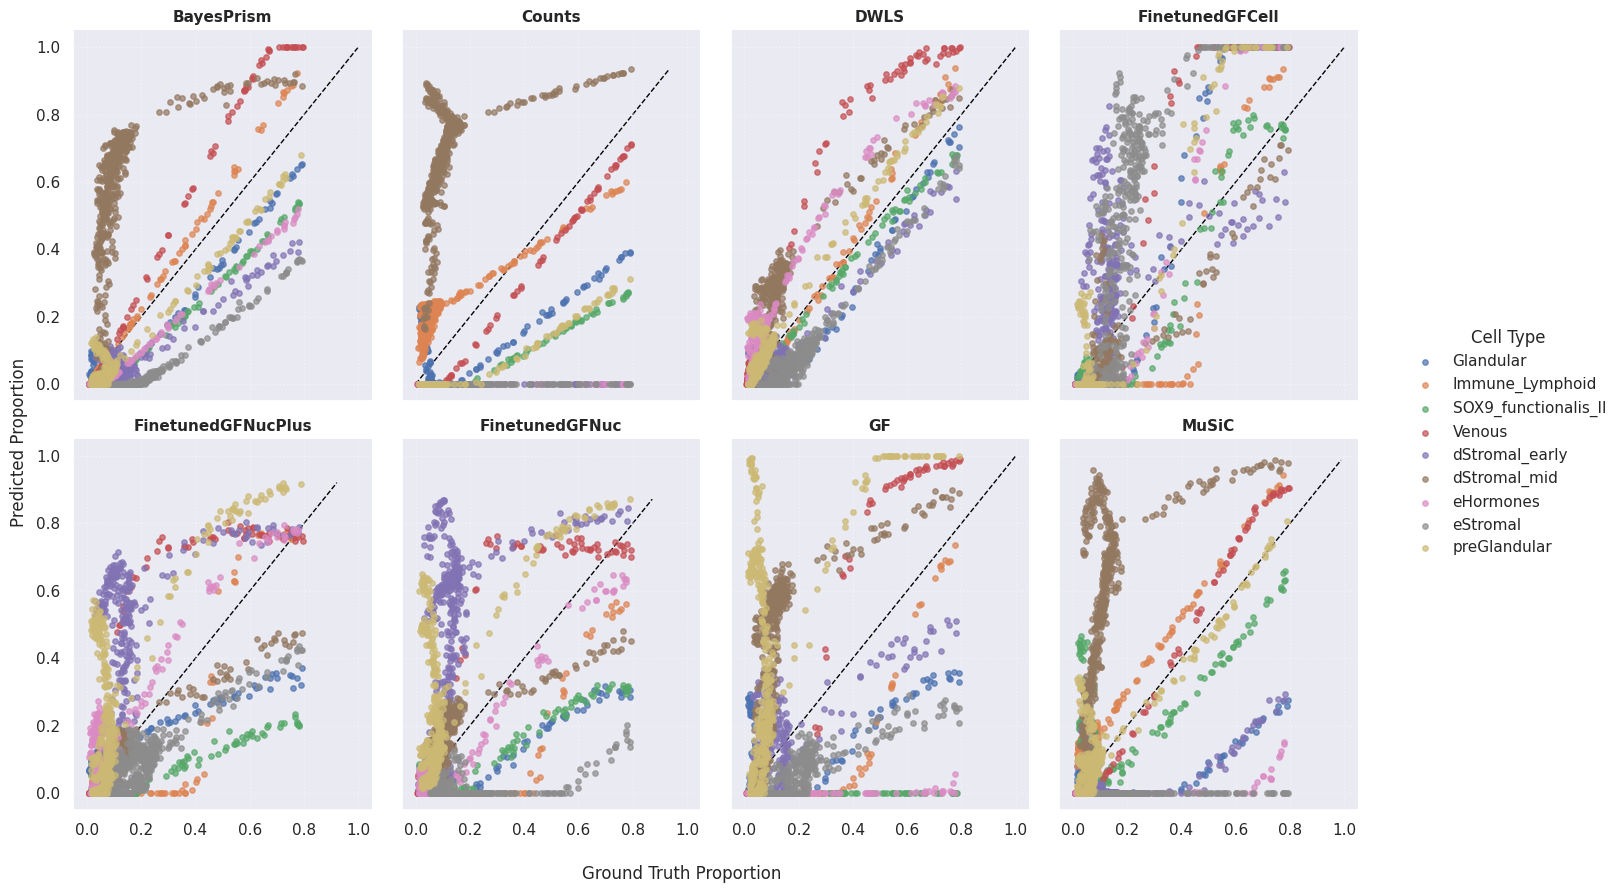

In [54]:
plot_prediction_scatter(results_path = "../results/czi_cell_type/", true_df=cell_prop)

### Fine-Tune on HECA

In [30]:
from deconversation import models as md

geneformer successfully imported.
Cell2Sentence is not installed. Skipping related functions.


In [31]:
adata_ref = pr.load_and_prep_data(adata = adata_ref, cell_type_col= "celltype", mode="geneformer")

/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/deconversation/preprocessing.py:51: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["cell_id"] = adata.obs.index


In [32]:
adata_ref.var.index.name = None

In [33]:
#200 500 1000 2000 5000

In [34]:
sub_indices = (
    adata_ref.obs.groupby("celltype", observed=False)
    .sample(n=200, random_state=42)
    .index
)

adata_sub = adata_ref[sub_indices].copy()

In [35]:
adata_sub.obs["celltype"].value_counts()

celltype
SOX9_functionalis_II    200
preGlandular            200
Glandular               200
eHormones               200
eStromal                200
dStromal_early          200
dStromal_mid            200
Immune_Lymphoid         200
Venous                  200
Name: count, dtype: int64

In [127]:
#adata_sub.write_h5ad("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/HECA_nuc/HECA_marcokeva_nuc_only_for_finetuning.h5ad")

In [21]:
gf_finetuned_metrics =  md.train_geneformer_cell_classifier(adata_sub,
                                                        output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/HECA_nuc/",
                                                        state_key = "celltype",
                                                        cell_types = None,
                                                        tokenize = False,
                                                        tokenized_data_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/HECA_nuc/tokenized/tokenized.dataset/", 
                                                        token_output_prefix = "tokenized", 
                                                        undersample = True,  
                                                        n_per_class = 1500, # 
                                                        n_test_per_class = 80, 
                                                        eval_fraction = 0.2, 
                                                        model_directory = "ctheodoris/Geneformer",
                                                        freeze_layers = 2, 
                                                        num_crossval_splits = 1,
                                                        forward_batch_size = 10,
                                                        nproc = 8,
                                                        max_ncells = None, 
                                                        training_args = {"num_train_epochs": 3}, 
                                                        output_prefix = "gf_finetune",
                                                        metrics_output_dir = None, 
                                                       )

2026-08-20 15:09:30,393 [INFO] Training arguments: {'num_train_epochs': 3, 'learning_rate': 5e-05, 'lr_scheduler_type': 'cosine', 'warmup_steps': 190, 'weight_decay': 0.1, 'per_device_train_batch_size': 4, 'gradient_accumulation_steps': 8, 'seed': 42, 'fp16': True}
2026-08-20 15:09:30,394 [INFO] Skipping tokenization. Using: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/HECA_nuc/tokenized/tokenized.dataset/
2026-08-20 15:09:30,395 [INFO] Undersampling: max 1500 cells per class
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/deconversation/models.py:175: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  metadata
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/deconversation/models.p

  0%|          | 0/1 [00:00<?, ?it/s]

****** Validation split: 1/1 ******



mkdir: cannot create directory ‘/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/HECA_nuc/260820_geneformer_cellClassifier_gf_finetune/ksplit1’: File exists
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ctheodoris/Geneformer and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/geneformer/collator_for_classification.py:649: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  batch = {k: torch.tensor(v.clone().detach(), dtype=torch.int64) if isinstance(v, torch.Tensor) else torch.tensor(v, dtype=to

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.651800,0.257475,0.932593,0.931971
2,0.225600,0.212392,0.942222,0.942171
3,0.166200,0.234292,0.939630,0.939631


/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/geneformer/collator_for_classification.py:649: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  batch = {k: torch.tensor(v.clone().detach(), dtype=torch.int64) if isinstance(v, torch.Tensor) else torch.tensor(v, dtype=torch.int64) for k, v in batch.items()}
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/geneformer/collator_for_classification.py:649: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  batch = {k: torch.tensor(v.clone().detach(), dtype=torch.int64) if isinstance(v, torch.Tensor) else torch.tensor(v, dtype=torch.int64) for k, v in batch.items()}


  0%|          | 0/270 [00:00<?, ?it/s]

2026-08-20 16:12:03,116 [INFO] Evaluating on test set…


  0%|          | 0/72 [00:00<?, ?it/s]

2026-08-20 16:13:07,800 [INFO] Metrics saved to /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/HECA_nuc/metrics/gf_finetune_metrics.pkl
2026-08-20 16:13:07,801 [INFO] Done.


In [22]:
conf_matrix = gf_finetuned_metrics["test_metrics"]["conf_matrix"]

In [23]:
# Empty data frame to store fine tuning results 
metrics = pd.DataFrame(index=conf_matrix.index, columns=["Precision", "Recall", "F1", "Accuracy"])

for cls in conf_matrix.columns:
    tp = conf_matrix.loc[cls, cls]  # TP
    fp = conf_matrix[cls].sum() - tp  # FP
    fn = conf_matrix.loc[cls].sum() - tp  # FN
    tn = conf_matrix.values.sum() - (tp + fp + fn)  # TN

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    accuracy = (tp + tn) / conf_matrix.values.sum()

    metrics.loc[cls] = [precision, recall, f1, accuracy]

# Convert all to float and round for readability
metrics = metrics.astype(float).round(3)

# Sort by F1 score (descending order)
metrics = metrics.sort_values(by="F1", ascending=False)

print(metrics)

                      Precision  Recall     F1  Accuracy
Venous                    1.000   1.000  1.000     1.000
Immune_Lymphoid           0.976   1.000  0.988     0.997
Glandular                 0.975   0.988  0.981     0.996
preGlandular              0.975   0.988  0.981     0.996
SOX9_functionalis_II      0.963   0.975  0.969     0.993
eHormones                 0.973   0.912  0.942     0.988
eStromal                  0.872   0.938  0.904     0.978
dStromal_mid              0.869   0.912  0.890     0.975
dStromal_early            0.929   0.812  0.867     0.972


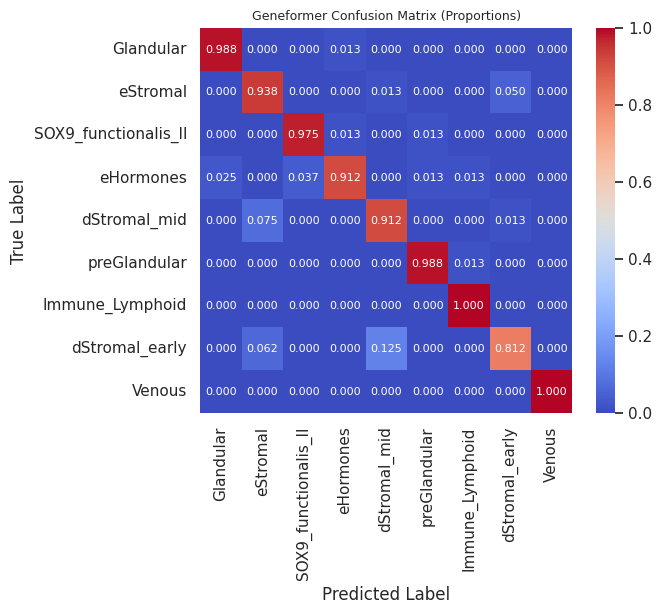

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

conf_matrix = gf_finetuned_metrics["test_metrics"]["conf_matrix"]

# Normalize the confusion matrix to proportions
conf_matrix_row_normalized = conf_matrix.div(conf_matrix.sum(axis=1), axis=0)

# Create the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix_row_normalized, 
    annot=True,                
    fmt=".3f",                 
    cmap="coolwarm",          
    annot_kws={"size": 8}      
)
plt.title("Geneformer Confusion Matrix (Proportions)", fontsize=9)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.show()